In [1]:
import pandas as pd
df = pd.read_csv("../Data/banking customer churn.csv")


In [2]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.drop(columns = ['RowNumber'], inplace=True)

In [4]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1.2 MB


In [6]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.to_parquet("../Data/Customer_Churn.parquet", engine='pyarrow', index=False)

In [8]:
df = pd.read_parquet("../Data/Customer_Churn.parquet", engine='pyarrow')

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Cau hinh hien thi bieu do
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

C:\Users\Asus\AppData\Local\Temp\ipykernel_7280\2230197517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Exited', data=df, palette='Set2')


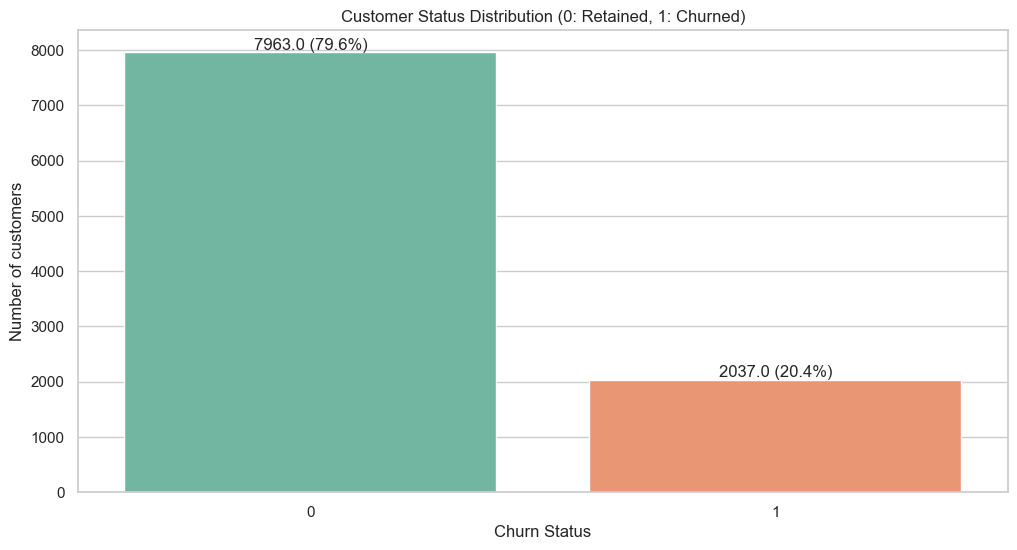

In [11]:
#Phan tich don bien
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='Exited', data=df, palette='Set2')
plt.title('Customer Status Distribution (0: Retained, 1: Churned)')
plt.xlabel('Churn Status')
plt.ylabel('Number of customers')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(df)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

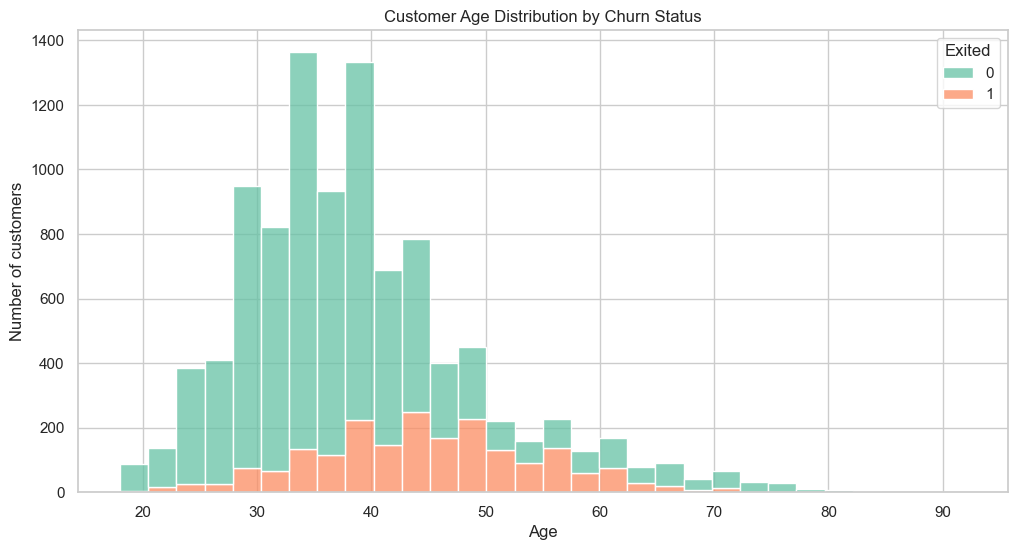

In [12]:
# Phan tich da bien va kiem chung gia dinh nghiep vu

# phan tich xu huong exited theo do tuoi
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Age', hue='Exited', multiple='stack', palette='Set2', bins=30)
plt.title('Customer Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.show

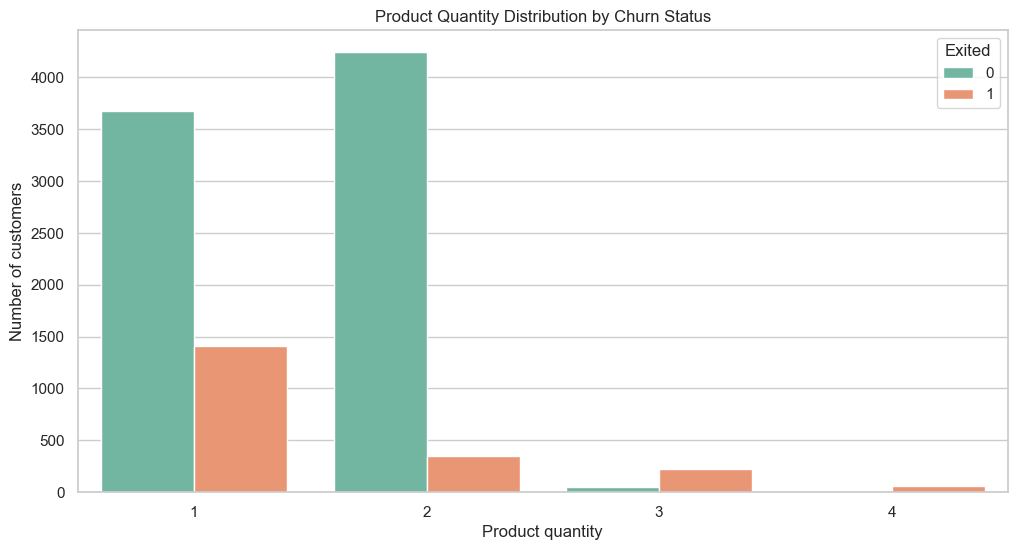

In [13]:
# ty le churn theo so luong san pham ma khach hang dang su dung
plt.figure(figsize=(12, 6))
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='Set2')
plt.title('Product Quantity Distribution by Churn Status')
plt.xlabel('Product quantity')
plt.ylabel('Number of customers')
plt.show()

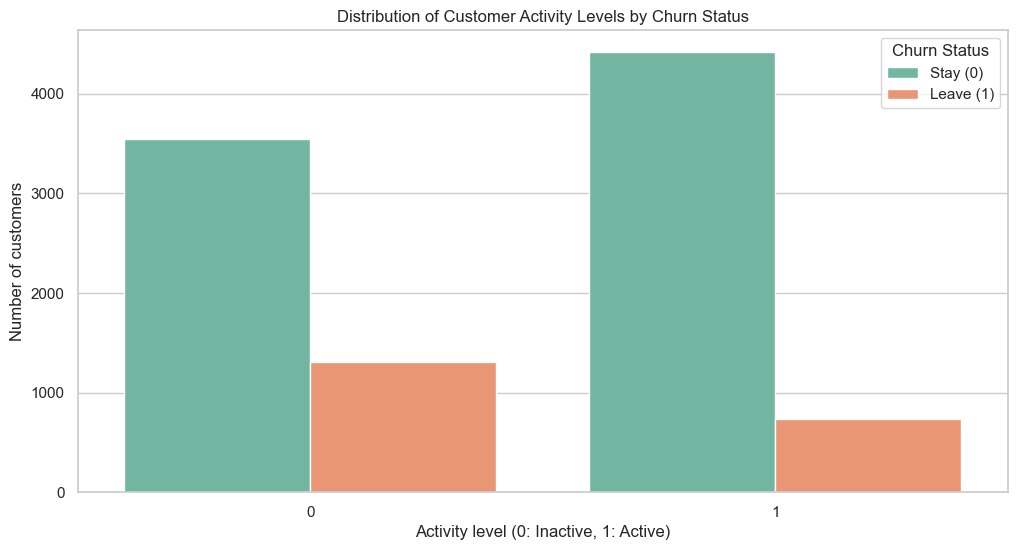

In [14]:
# ty le churn theo muc do hoat dong cua khach hang
plt.figure(figsize=(12, 6))
sns.countplot(x='IsActiveMember', hue='Exited', data=df, palette='Set2')
plt.title('Distribution of Customer Activity Levels by Churn Status')
plt.xlabel('Activity level (0: Inactive, 1: Active)')
plt.ylabel('Number of customers')
plt.legend(title='Churn Status', loc='upper right', labels=['Stay (0)', 'Leave (1)'])
plt.show()

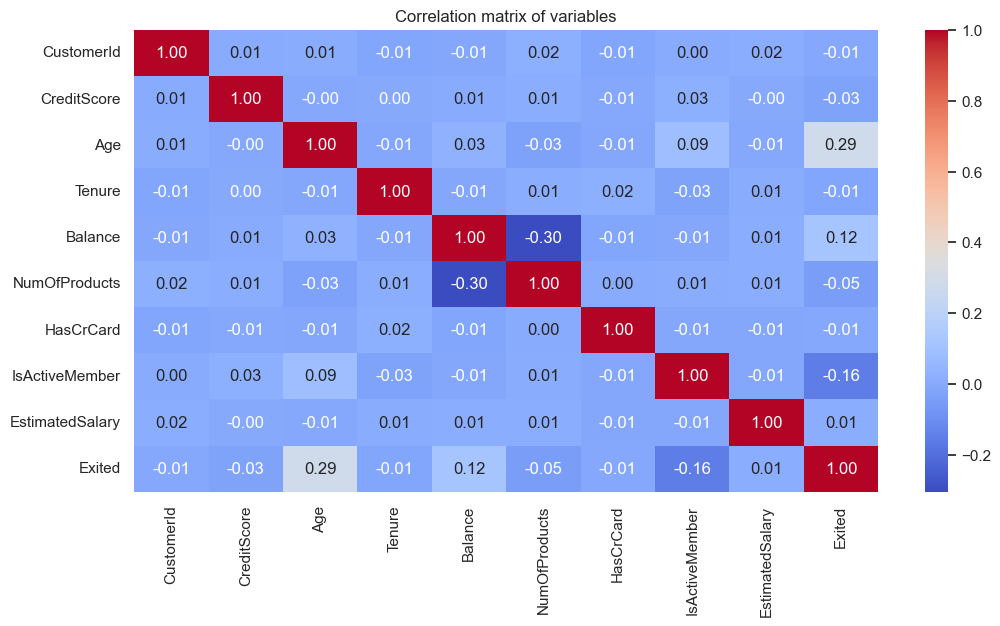

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix of variables')
plt.show()

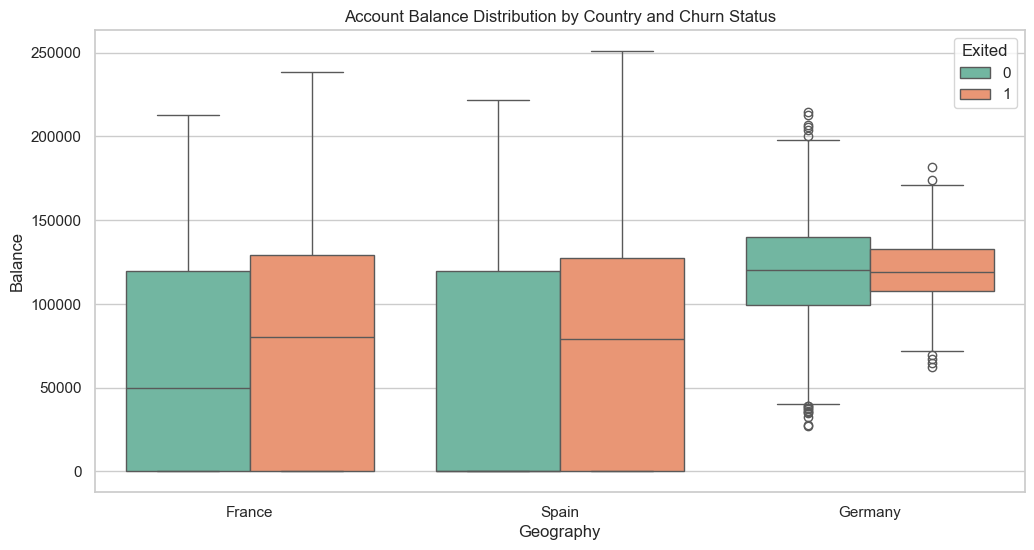

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = 'Geography', y = 'Balance', hue = 'Exited', data = df, palette='Set2')
plt.title('Account Balance Distribution by Country and Churn Status')
plt.xlabel('Geography')
plt.ylabel('Balance')
plt.show()

## Insights ##
- Mất cân bằng dữ liệu: Tỷ lệ khách hàng rời bỏ (Exited = 1) chiếm 20.4% trong khi khách hàng ở lại chiếm 79.6% -> Xử lý dữ liệu mất cân bằng (SMOTE hoặc trọng số lớp)
- Insight về độ tuổi: Biểu đồ mật độ (KDE Plot) sẽ chỉ ra rằng nhóm khách hàng trẻ tuổi (20 - 35) rất trung thành. Tuy nhiên, tỷ lệ rời bỏ đạt đỉnh cực cao ở nhóm tuổi từ 40 đến 50. Đây là một phát hiện bất ngờ, vì thông thường người ta nghĩ người trẻ dễ đổi ngân hàng hơn.
- Insight về số lượng sản phẩm: Nếu xét về sự tương quan giữa khách hàng rời bỏ và không rời bỏ đối với nhóm chỉ sử dụng 1 đến 2 sản phẩm thì nhóm 2 sản phẩm có tỷ lệ khách hàng rời bỏ thấp nhất. Tuy nhiên, đối với nhóm sử dụng 3 đến 4 sản phẩm thì tỷ lệ rời bỏ rất cao, vượt trội so với nhóm ở lại, cần tiến hành xem xét kỹ hơn đối với nhóm này.
- Đúng như dự đoán, nhóm khách hàng không hoạt động (active_member = 0) có tỷ lệ rời đi cao vượt trội so với nhóm có tương tác thường xuyên.
- Ở cả Pháp và Tây Ban Nha, các hộp màu xanh (Exited = 0 - ở lại) và màu cam (Exited = 1 - rời bỏ) đều có phần đáy (Q1 và Min) chạm mức 0. Điều này chứng tỏ hai quốc gia này sở hữu một lượng rất lớn khách hàng mở tài khoản nhưng không để tiền hoặc đã rút hết tiền. Insight cốt lõi: Nhóm khách hàng có số dư bằng 0 đa số lại chọn Ở lại (Màu xanh) hoặc ít nhất là họ chưa thực hiện thủ tục đóng tài khoản chính thức. Ngược lại, đối với những người thực sự rời đi (Màu cam), đường trung vị (vạch ngang giữa hộp) nằm cao hơn hẳn so với nhóm ở lại. Nghĩa là tại Pháp và Tây Ban Nha, ngân hàng đang đánh mất những khách hàng có tích lũy tài chính khá tốt (trung vị khoảng 80,000).
- Nước Đức mang một đặc điểm phân phối dòng tiền hoàn toàn khác biệt so với hai quốc gia còn lại. Cả hai hộp (ở lại và rời bỏ) đều nằm lơ lửng, phần đáy hộp (Min) chặn ở mức khoảng 25,000 - 40,000. Nghĩa là không có khách hàng 0 đồng nào ở Đức; mọi khách hàng tại đây đều duy trì một lượng tiền gửi đáng kể. Insight cốt lõi: Giá trị trung vị (Median) và biên độ dao động số dư của nhóm ở lại vs nhóm rời bỏ tại Đức gần như tương đương nhau (quanh mốc 120,000). Điều này chỉ ra rằng, bất kể khách hàng tại Đức giàu hay rất giàu, họ đều có tỷ lệ và hành vi rời bỏ tương tự nhau. Việc họ Churn không phụ thuộc vào việc họ có nhiều tiền hay ít tiền trong tài khoản, mà có thể do một vấn đề hệ thống mang tính thị trường tại Đức (ví dụ: đối thủ cạnh tranh có chính sách tốt hơn, hoặc phí dịch vụ tại Đức quá cao).
